# HMM Output Analysis

This notebook visualizes the outputs of the `03_fit_shared_hmm.py` script.
We will load the artifacts and generate plots for:
1. Model selection (held-out log-likelihood vs. K)
2. Emission probabilities for the best model
3. Transition matrix for the best model
4. Regime prevalence (mean occupancy)
5. A graph of high-probability transitions

In [15]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Global plotting style
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["svg.fonttype"] = "none"  # Editable text in SVG

In [16]:
# --- Configuration ---
ARTIFACTS_DIR = Path("../artifacts/chmm")
PROCESSED_DIR = Path("../data/processed")
REPO_ROOT = Path("..")

# --- Load Data ---
try:
    df_selection = pd.read_csv(ARTIFACTS_DIR / "model_selection.csv")
    with open(ARTIFACTS_DIR / "best_model.json") as f:
        params = json.load(f)
    
    best_K = params["K"]
    pT = np.array(params["pT"])
    pC = np.array(params["pC"])
    A = np.array(params["A"])
    
    df_decoded = pd.read_csv(ARTIFACTS_DIR / "decoded_sessions.csv")
    
    print(f"Successfully loaded artifacts for K={best_K}.")
    
except FileNotFoundError as e:
    print(f"Error loading artifacts: {e}")
    print("Please run the `make analysis` command to generate HMM results first.")

Successfully loaded artifacts for K=8.


### 1. Model Selection Curve

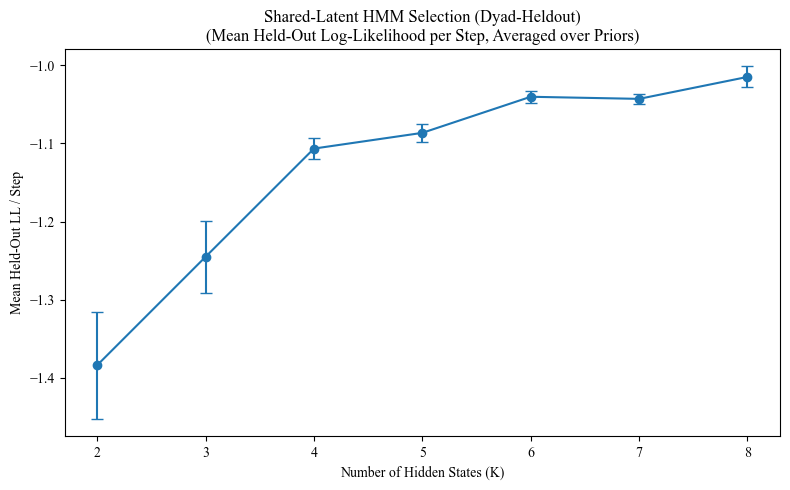

In [28]:
def plot_selection_curve(df: pd.DataFrame):
    """Plots the model selection curve (LL/step vs. K)."""
    byK = df.groupby("K")["test_ll_per_step"].agg(["mean", "sem"]).reset_index().sort_values("K")
    
    plt.figure(figsize=(8, 5))
    plt.errorbar(byK["K"], byK["mean"], yerr=byK["sem"], marker="o", capsize=4, linestyle='-')
    plt.title(
        "Shared-Latent HMM Selection (Dyad-Heldout)\n"
        "(Mean Held-Out Log-Likelihood per Step, Averaged over Priors)"
    )
    plt.xlabel("Number of Hidden States (K)")
    plt.ylabel("Mean Held-Out LL / Step")
    plt.tight_layout()
    plt.show()

if 'df_selection' in locals():
    plot_selection_curve(df_selection)

### 2. Emission Profiles

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_10405/1223959212.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


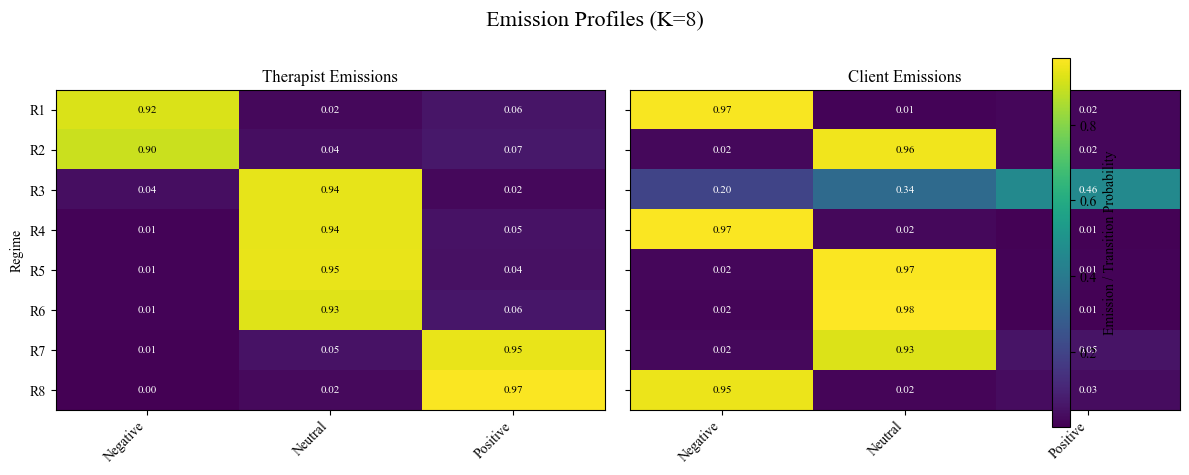

In [19]:
def plot_emissions(pT: np.ndarray, pC: np.ndarray, K: int, vmin=None, vmax=None, save_path=None):
    """Plots the emission probability matrices for therapist and client with a shared colorbar."""
    n_emit = pT.shape[1]

    # Get code names
    if n_emit == 3:
        code_names = ["Negative", "Neutral", "Positive"]
    else:
        try:
            spaff_codes = pd.read_csv(REPO_ROOT / "spaff_codes.csv")
            code_names = spaff_codes["code_name"].tolist()
        except FileNotFoundError:
            code_names = [f"Code {i}" for i in range(n_emit)]

    # Sort regimes for interpretability
    order, regime_labels = _regime_order_and_labels(pT, pC)
    pT_sorted = pT[order]
    pC_sorted = pC[order]

    # Shared color scale
    if vmin is None:
        vmin = min(pT.min(), pC.min())
    if vmax is None:
        vmax = max(pT.max(), pC.max())

    fig, axes = plt.subplots(1, 2, figsize=(12, max(4, 0.6 * K)), sharey=True)

    # Therapist emissions
    im0 = axes[0].imshow(pT_sorted, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    axes[0].set_title("Therapist Emissions")
    axes[0].set_ylabel("Regime")
    axes[0].set_yticks(np.arange(K))
    axes[0].set_yticklabels(regime_labels)
    axes[0].set_xticks(np.arange(len(code_names)))
    axes[0].set_xticklabels(code_names, rotation=45, ha="right")

    # Client emissions
    im1 = axes[1].imshow(pC_sorted, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    axes[1].set_title("Client Emissions")
    axes[1].set_xticks(np.arange(len(code_names)))
    axes[1].set_xticklabels(code_names, rotation=45, ha="right")

    # Add numeric annotations
    for i in range(K):
        for j in range(len(code_names)):
            axes[0].text(j, i, f"{pT_sorted[i, j]:.2f}", ha="center", va="center", fontsize=8,
                         color="white" if pT_sorted[i, j] < 0.5 * vmax else "black")
            axes[1].text(j, i, f"{pC_sorted[i, j]:.2f}", ha="center", va="center", fontsize=8,
                         color="white" if pC_sorted[i, j] < 0.5 * vmax else "black")

    # Place a single colorbar to the right of both subplots
    cbar = fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.025, pad=0.04, label="Emission / Transition Probability")
    fig.suptitle(f"Emission Profiles (K={K})", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if save_path is not None:
        fig.savefig(save_path, format="svg")
    plt.show()

if 'pT' in locals():
    vmin = min(pT.min(), pC.min(), A.min()) if 'A' in locals() else min(pT.min(), pC.min())
    vmax = max(pT.max(), pC.max(), A.max()) if 'A' in locals() else max(pT.max(), pC.max())
    plot_emissions(pT, pC, best_K, vmin=vmin, vmax=vmax, save_path=ARTIFACTS_DIR / "emission_profiles.svg")

### 3. Transition Matrix

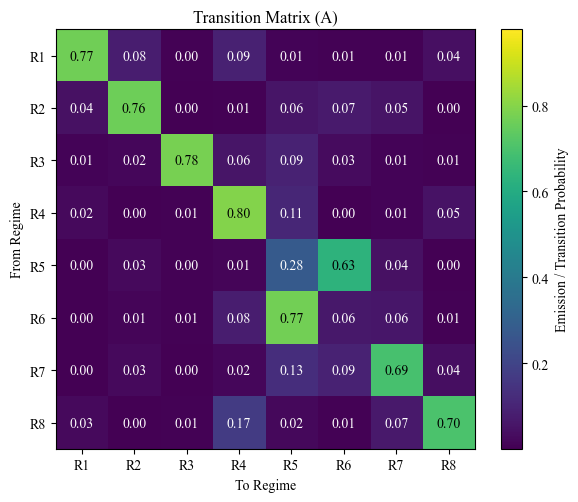

In [20]:
def plot_transition_matrix(A: np.ndarray, K: int, pT: np.ndarray, pC: np.ndarray, vmin=None, vmax=None, save_path=None):
    """Plots the transition matrix, reordering states for interpretability, using a shared colorbar."""
    order, regime_labels = _regime_order_and_labels(pT, pC)
    A_sorted = A[order][:, order]

    if vmin is None:
        vmin = min(A.min(), pT.min(), pC.min())
    if vmax is None:
        vmax = max(A.max(), pT.max(), pC.max())

    plt.figure(figsize=(6, 5))
    im = plt.imshow(A_sorted, cmap="viridis", vmin=vmin, vmax=vmax)
    
    plt.title("Transition Matrix (A)")
    plt.xlabel("To Regime")
    plt.ylabel("From Regime")
    
    tick_labels = [label for label in regime_labels]
    plt.xticks(np.arange(K), tick_labels)
    plt.yticks(np.arange(K), tick_labels)

    # Annotate with probabilities
    for i in range(K):
        for j in range(K):
            plt.text(j, i, f"{A_sorted[i, j]:.2f}", ha="center", va="center",
                     color="white" if A_sorted[i, j] < 0.5 * vmax else "black")

    plt.colorbar(im, label="Emission / Transition Probability")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, format="svg")
    plt.show()

if 'A' in locals():
    vmin = min(pT.min(), pC.min(), A.min())
    vmax = max(pT.max(), pC.max(), A.max())
    plot_transition_matrix(A, best_K, pT, pC, vmin=vmin, vmax=vmax, save_path=ARTIFACTS_DIR / "transition_matrix.svg")

### 4. Regime Prevalence

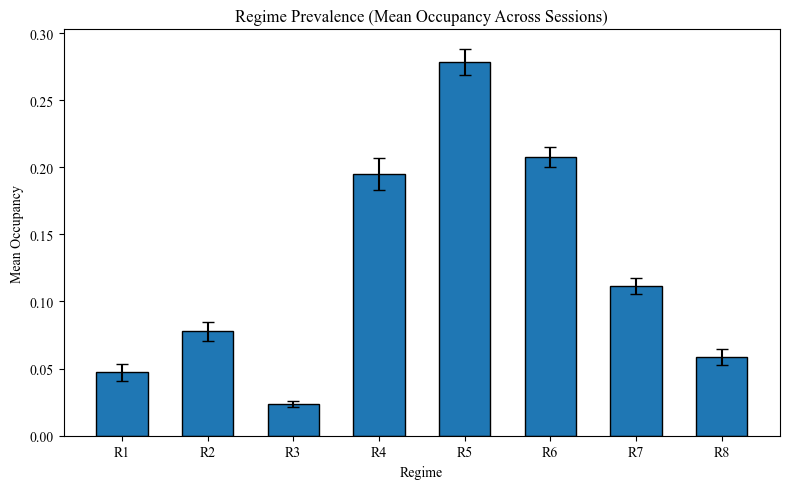

In [27]:
def plot_regime_prevalence(decoded_df: pd.DataFrame, K: int, pT: np.ndarray, pC: np.ndarray, save_path=None):
    """Bar plot of mean occupancy across sessions with error bars."""
    order, regime_labels = _regime_order_and_labels(pT, pC)
    
    occ_cols = [f"occ_{k}" for k in range(K)]
    occ_data = decoded_df[occ_cols].to_numpy()
    
    # Reorder according to canonical regime order
    occ_data_sorted = occ_data[:, order]
    
    means = occ_data_sorted.mean(axis=0)
    ses = occ_data_sorted.std(axis=0, ddof=1) / np.sqrt(len(occ_data_sorted))

    tick_labels = [label for label in regime_labels]
    
    plt.figure(figsize=(8, 5))
    plt.bar(tick_labels, means, yerr=ses, capsize=4, edgecolor='black', width=0.6)
    
    plt.ylabel("Mean Occupancy")
    plt.xlabel("Regime")
    plt.title("Regime Prevalence (Mean Occupancy Across Sessions)")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, format="svg")
    plt.show()

if 'df_decoded' in locals():
    plot_regime_prevalence(df_decoded, best_K, pT, pC, save_path=ARTIFACTS_DIR / "regime_prevalence.svg")

### 5. Regime Transition Graph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 7.9 MB/s  0:00:009.4 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.
Order: [5 6 3 2 1 0 7 4]


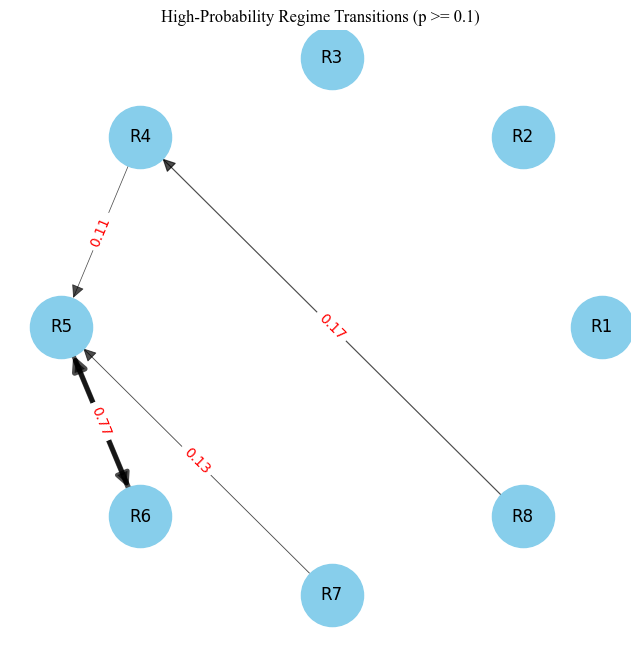

In [ ]:
%pip install networkx

def plot_transition_graph(A: np.ndarray, K: int, pT: np.ndarray, pC: np.ndarray, threshold: float = 0.1, save_path=None):
    """Directed graph of high-probability transitions between regimes."""
    order, regime_labels = _regime_order_and_labels(pT, pC)
    A_sorted = A[order][:, order]
    tick_labels = [label for label in regime_labels]

    # Create a graph
    import networkx as nx
    G = nx.DiGraph()

    for i in range(K):
        G.add_node(i, label=tick_labels[i])

    for i in range(K):
        for j in range(K):
            p = A_sorted[i, j]
            if i != j and p >= threshold:
                G.add_edge(i, j, weight=p, label=f"{p:.2f}")

    plt.figure(figsize=(8, 8))
    pos = nx.circular_layout(G)
    
    node_labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="skyblue")
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12)
    
    edges = G.edges(data=True)
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=edges,
        width=[d['weight'] * 5 for _, _, d in edges],
        alpha=0.7,
        arrowsize=20,
        node_size=2000,
    )
    
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

    plt.title("High-Probability Regime Transitions (p >= 0.1)")
    plt.axis("off")
    if save_path is not None:
        plt.savefig(save_path, format="svg")
    plt.show()

if 'A' in locals():
    plot_transition_graph(A, best_K, pT, pC, save_path=ARTIFACTS_DIR / "regime_transition_graph.svg")